In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data preparing

## 1 GPU

In [25]:
res_1gpu = pd.read_csv('results_from_athena_numsamples/bioemu_results.numsamples.bioemu_numsamples_1gpu.csv')

res_1gpu.head()

,experiment,job_id,node,rank,n_gpus,gpu_name,seq_range,fasta_file,seq_len,phase,cache_warm,num_samples,batch_size,wall_time_s,peak_vram_mb,status
0,numsamples,2671009,t0004,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,warmup,False,1,50,3.96,174.0,ok
1,numsamples,2671009,t0004,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,10,50,3.58,507.8,ok
2,numsamples,2671009,t0004,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,25,50,6.70,1049.7,ok
3,numsamples,2671009,t0004,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,50,50,12.22,1945.7,ok
4,numsamples,2671009,t0004,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,100,50,23.29,3570.7,ok


In [26]:
res_1gpu.shape

(161, 16)

In [27]:
res_1gpu_ok = res_1gpu[res_1gpu["status"] == "ok"]
res_1gpu_ok.shape

(159, 16)

In [28]:
res_1gpu_ok_warmup = res_1gpu_ok[res_1gpu_ok["phase"] == "warmup"]
res_1gpu_ok_warmup.shape

(20, 16)

Actual runs:

In [29]:
res_1gpu_ok = res_1gpu_ok[res_1gpu_ok["phase"] != "warmup"]
res_1gpu_ok.shape

(139, 16)

num_samples values tested:

In [30]:
ns_values = sorted(res_1gpu_ok["num_samples"].unique())
ns_values

[np.int64(10),
 np.int64(25),
 np.int64(50),
 np.int64(100),
 np.int64(200),
 np.int64(500),
 np.int64(1000)]

## 8 GPU

In [31]:
res_8gpu = pd.read_csv('results_from_athena_numsamples/numsamples_8gpu_merged.csv')

res_8gpu.head()

,experiment,job_id,node,rank,n_gpus,gpu_name,seq_range,fasta_file,seq_len,phase,cache_warm,num_samples,batch_size,wall_time_s,peak_vram_mb,status
0,numsamples,2671010,t0030,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,warmup,False,1,50,8.76,0.0,ok
1,numsamples,2671010,t0030,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,10,50,11.01,0.0,ok
2,numsamples,2671010,t0030,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,25,50,17.18,0.0,ok
3,numsamples,2671010,t0030,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,50,50,23.00,0.0,ok
4,numsamples,2671010,t0030,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001648_00738.fasta,72,sample,True,100,50,35.57,0.0,ok


In [32]:
res_8gpu.shape

(163, 16)

In [33]:
res_8gpu_ok = res_8gpu[res_8gpu["status"] == "ok"]
res_8gpu_ok.shape

(153, 16)

In [34]:
res_8gpu_ok_warmup = res_8gpu_ok[res_8gpu_ok["phase"] == "warmup"]
res_8gpu_ok_warmup.shape

(20, 16)

In [35]:
res_8gpu_ok = res_8gpu_ok[res_8gpu_ok["phase"] != "warmup"]
res_8gpu_ok.shape

(133, 16)

## Errors

In [36]:
error_1gpu = res_1gpu[res_1gpu["status"] != "ok"]
error_1gpu[["seq_range", "fasta_file", "num_samples", "status"]]

,seq_range,fasta_file,num_samples,status
40,50-100aa,MGYG000139077_02576.fasta,1,ERROR: Invalid suffix '_unphysical.xtc'
57,50-100aa,MGYG000190757_00999.fasta,1,ERROR: Invalid suffix '_unphysical.xtc'


In [37]:
error_8gpu = res_8gpu[res_8gpu["status"] != "ok"]
error_8gpu[["seq_range", "fasta_file", "num_samples", "status"]]

,seq_range,fasta_file,num_samples,status
8,50-100aa,MGYG000190757_00999.fasta,1,ERROR: Invalid suffix '_unphysical.xtc'
17,501-1000aa,MGYG000001479_01649.fasta,1,ERROR: Invalid suffix '_unphysical.xtc'
112,501-1000aa,MGYG000000477_01569.fasta,500,ERROR: Not sure why /net/tscratch/people/plges...
113,50-100aa,MGYG000139077_02576.fasta,1,ERROR: Invalid suffix '_unphysical.xtc'
119,101-500aa,MGYG000002818_01096.fasta,200,ERROR: Not sure why /net/tscratch/people/plges...
120,101-500aa,MGYG000002818_01096.fasta,500,ERROR: Not sure why /net/tscratch/people/plges...
121,101-500aa,MGYG000002818_01096.fasta,1000,ERROR: Not sure why /net/tscratch/people/plges...
144,101-500aa,MGYG000004730_00424.fasta,1000,ERROR: Not sure why /net/tscratch/people/plges...
145,501-1000aa,MGYG000001250_01095.fasta,1,ERROR: range() arg 3 must not be zero
162,501-1000aa,MGYG000001451_04612.fasta,1,ERROR: range() arg 3 must not be zero


# Benchmark

## Time vs sequence length (one series per num_samples)

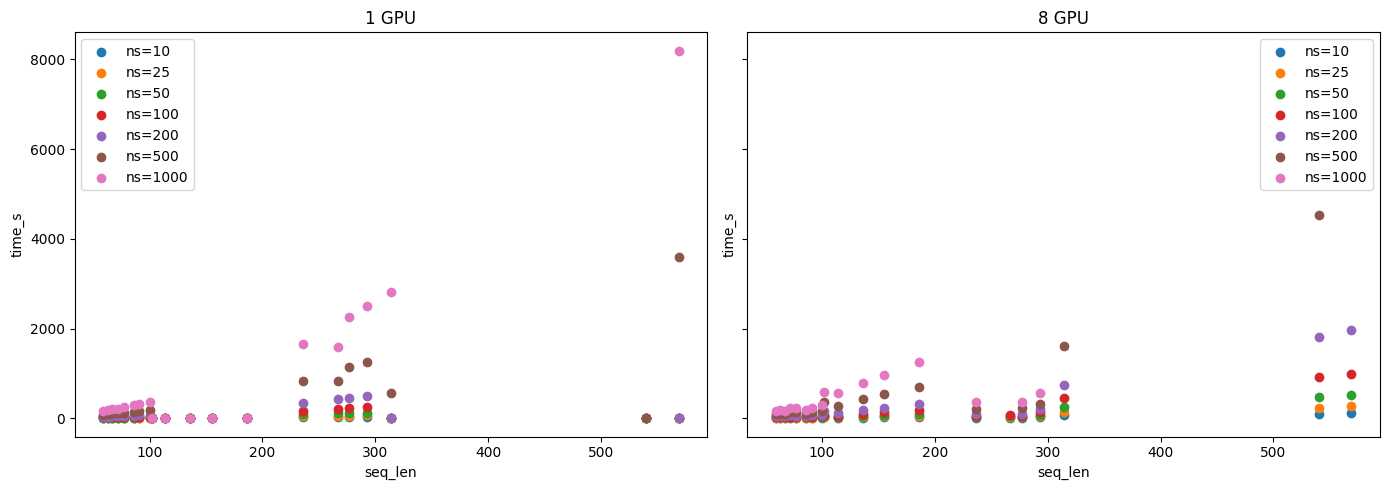

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ns in ns_values:
    sub = res_1gpu_ok[res_1gpu_ok["num_samples"] == ns]
    axes[0].scatter(sub["seq_len"], sub["wall_time_s"], label=f"ns={ns}")
axes[0].set_title("1 GPU")

for ns in ns_values:
    sub = res_8gpu_ok[res_8gpu_ok["num_samples"] == ns]
    axes[1].scatter(sub["seq_len"], sub["wall_time_s"], label=f"ns={ns}")
axes[1].set_title("8 GPU")

for ax in axes:
    ax.set_xlabel("seq_len")
    ax.set_ylabel("time_s")
    ax.legend()

plt.tight_layout()
plt.show()

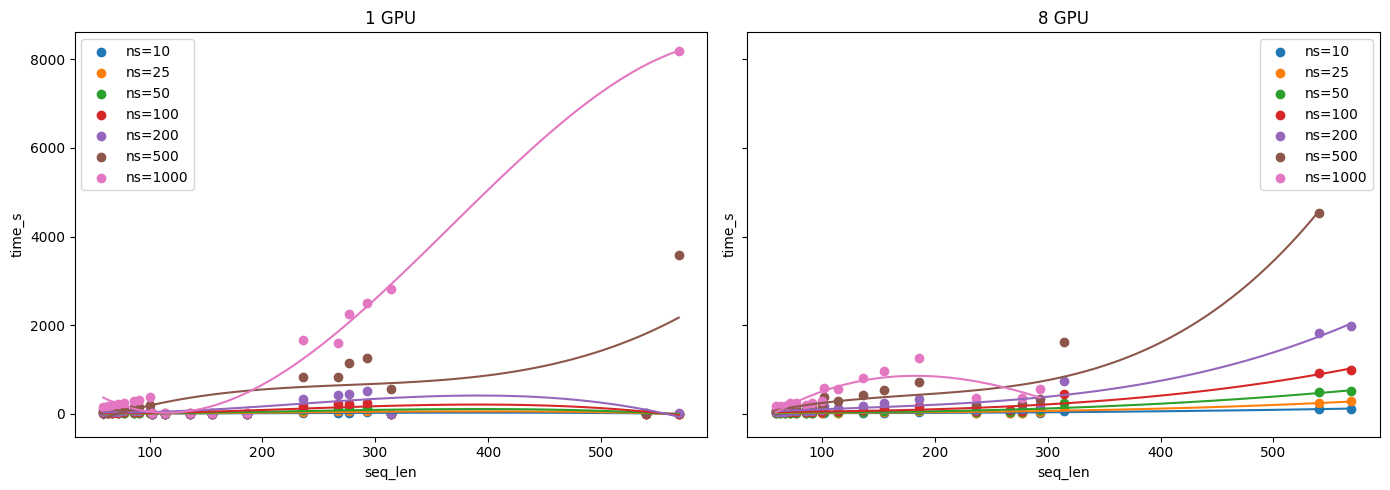

In [42]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ns in ns_values:
    sub = res_1gpu_ok[res_1gpu_ok["num_samples"] == ns]

    x = sub["seq_len"]
    y = sub["wall_time_s"]

    axes[0].scatter(x, y, label=f"ns={ns}")

    # dopasowanie prostej
    coef = np.polyfit(x, y, 3)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coef, x_fit)

    axes[0].plot(x_fit, y_fit)

axes[0].set_title("1 GPU")

for ns in ns_values:
    sub = res_8gpu_ok[res_8gpu_ok["num_samples"] == ns]

    x = sub["seq_len"]
    y = sub["wall_time_s"]

    axes[1].scatter(x, y, label=f"ns={ns}")

    coef = np.polyfit(x, y, 3)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coef, x_fit)

    axes[1].plot(x_fit, y_fit)

axes[1].set_title("8 GPU")

for ax in axes:
    ax.set_xlabel("seq_len")
    ax.set_ylabel("time_s")
    ax.legend()

plt.tight_layout()
plt.show()

## Time vs num_samples (one line per protein, expected linear)

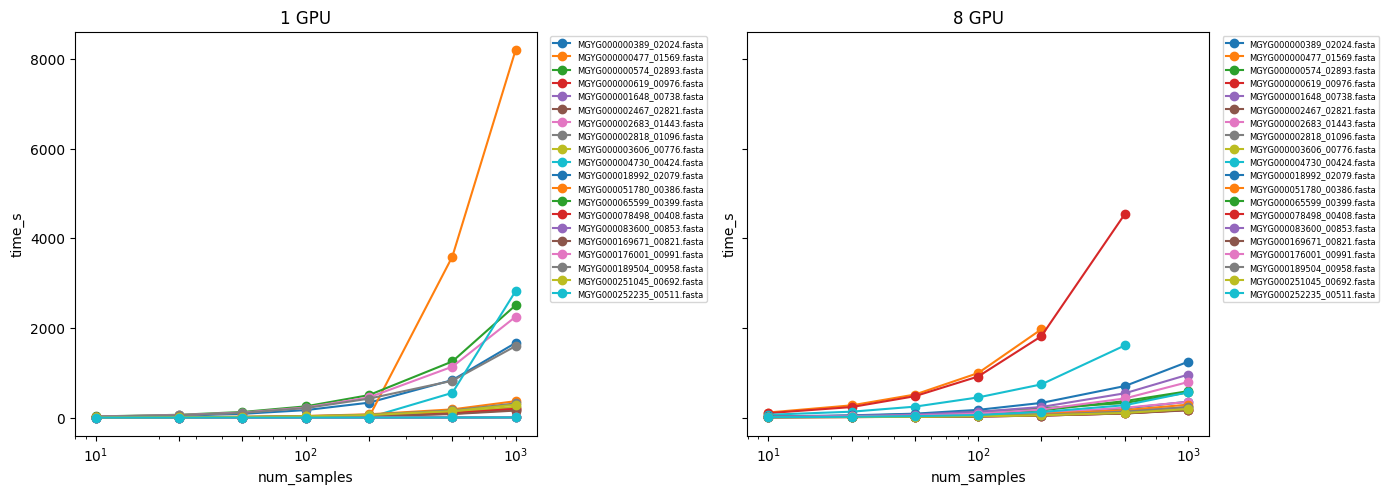

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

for fp in sorted(res_1gpu_ok["fasta_file"].unique()):
    sub = res_1gpu_ok[res_1gpu_ok["fasta_file"] == fp].sort_values("num_samples")
    axes[0].plot(sub["num_samples"], sub["wall_time_s"], marker="o", label=fp)
axes[0].set_title("1 GPU")

for fp in sorted(res_8gpu_ok["fasta_file"].unique()):
    sub = res_8gpu_ok[res_8gpu_ok["fasta_file"] == fp].sort_values("num_samples")
    axes[1].plot(sub["num_samples"], sub["wall_time_s"], marker="o", label=fp)
axes[1].set_title("8 GPU")

for ax in axes:
    ax.set_xlabel("num_samples")
    ax.set_ylabel("time_s")
    # 20+ proteins -> legend pushed outside the plot area for readability
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=6)

plt.tight_layout()
plt.xscale('log')
plt.xticks([10,25,50,100,200,500,1000])
plt.show()

Same plot, color-coded by seq_range bucket (linear check is easier without per-protein noise):

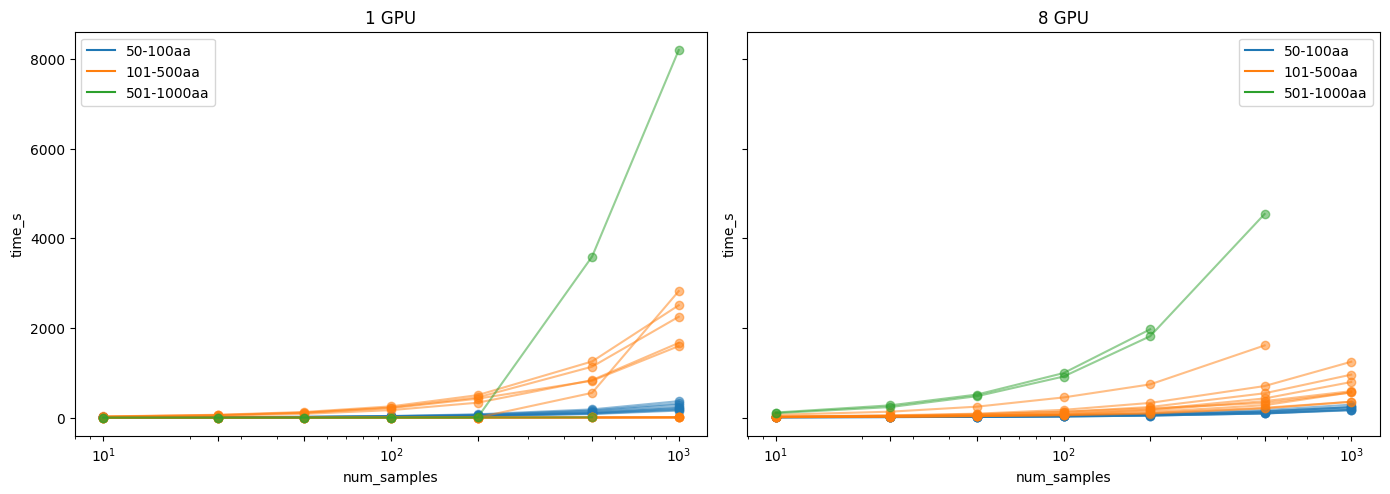

In [50]:
bucket_color = {"50-100aa": "tab:blue", "101-500aa": "tab:orange", "501-1000aa": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

for sr, c in bucket_color.items():
    sub_all = res_1gpu_ok[res_1gpu_ok["seq_range"] == sr]
    for fp in sub_all["fasta_file"].unique():
        sub = sub_all[sub_all["fasta_file"] == fp].sort_values("num_samples")
        axes[0].plot(sub["num_samples"], sub["wall_time_s"], marker="o", color=c, alpha=0.5)
    axes[0].plot([], [], color=c, label=sr)  # single legend entry per bucket
axes[0].set_title("1 GPU")

for sr, c in bucket_color.items():
    sub_all = res_8gpu_ok[res_8gpu_ok["seq_range"] == sr]
    for fp in sub_all["fasta_file"].unique():
        sub = sub_all[sub_all["fasta_file"] == fp].sort_values("num_samples")
        axes[1].plot(sub["num_samples"], sub["wall_time_s"], marker="o", color=c, alpha=0.5)
    axes[1].plot([], [], color=c, label=sr)
axes[1].set_title("8 GPU")

for ax in axes:
    ax.set_xlabel("num_samples")
    ax.set_ylabel("time_s")
    ax.legend()

plt.tight_layout()
plt.xscale('log')
plt.xticks([10,25,50,100,200,500,1000])
plt.show()

## VRAM vs sequence length (one series per num_samples)

Note: the 8 GPU run reports many `peak_vram_mb=0.0` rows — bioemu spawns its embedding step in a subprocess, so on some ranks the parent process's CUDA stats are zero. The 1 GPU numbers are clean.

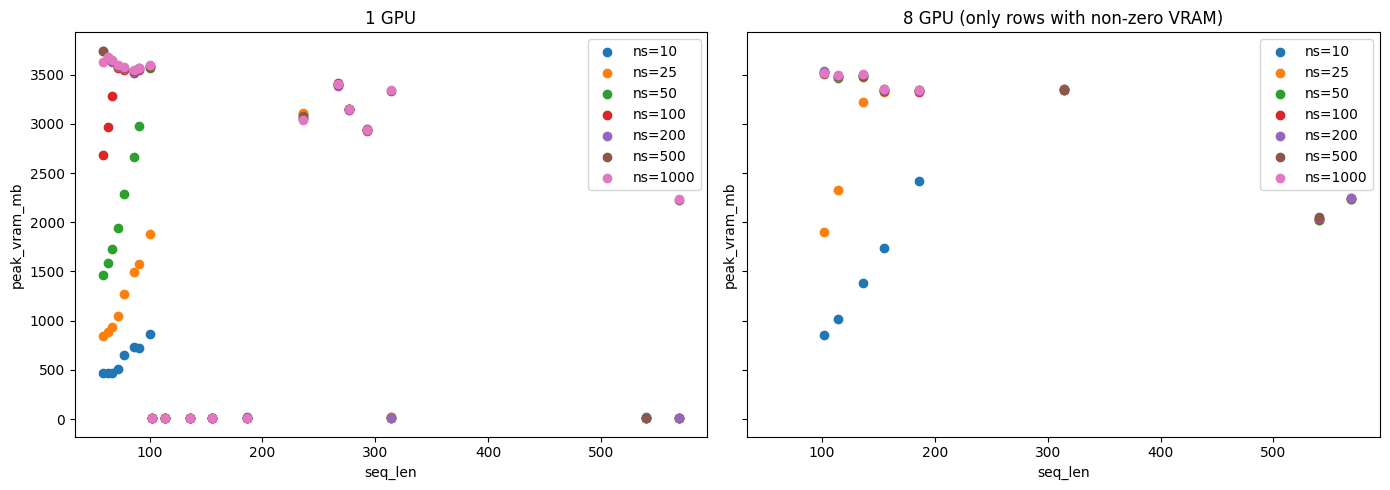

In [65]:
# Drop the broken (==0) rows so the chart only shows real measurements.
vram_1gpu = res_1gpu_ok[res_1gpu_ok["peak_vram_mb"] > 0]
vram_8gpu = res_8gpu_ok[res_8gpu_ok["peak_vram_mb"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

for ns in ns_values:
    sub = vram_1gpu[vram_1gpu["num_samples"] == ns]
    axes[0].scatter(sub["seq_len"], sub["peak_vram_mb"], label=f"ns={ns}")
axes[0].set_title("1 GPU")

for ns in ns_values:
    sub = vram_8gpu[vram_8gpu["num_samples"] == ns]
    axes[1].scatter(sub["seq_len"], sub["peak_vram_mb"], label=f"ns={ns}")
axes[1].set_title("8 GPU (only rows with non-zero VRAM)")

for ax in axes:
    ax.set_xlabel("seq_len")
    ax.set_ylabel("peak_vram_mb")
    ax.legend()

plt.tight_layout()
plt.show()

## Samples requested vs samples actually returned (filter rejection rate)

bioemu runs with `filter_samples=True`, so some sampled structures get dropped as "unphysical". The CSV only tells us whether the run finished (`status == ok`) — not how many of the requested `num_samples` survived the filter. Two views:

1. **Completion rate from CSV** — proxy showing how many runs finished without an error per (num_samples, seq_range).
2. **Actual returned count** — requires reading `samples.xtc` frame counts from `bioemu_outputs/numsamples/...`. Run `python count_samples_returned.py` (on Athena or wherever the outputs live) to generate `samples_returned.csv`, then the next cell will load and plot it.

In [22]:
# Proxy: how many runs finished without error, broken down by num_samples and seq_range.
all_runs = pd.concat([
    res_1gpu.assign(setup="1gpu"),
    res_8gpu.assign(setup="8gpu"),
], ignore_index=True)
all_runs = all_runs[all_runs["phase"] == "sample"]

completion = (all_runs
              .assign(ok=lambda d: (d["status"] == "ok").astype(int))
              .groupby(["setup", "seq_range", "num_samples"])
              .agg(n=("ok", "size"), n_ok=("ok", "sum"))
              .assign(completion_rate=lambda d: (d["n_ok"] / d["n"]).round(2))
              .reset_index())
completion

,setup,seq_range,num_samples,n,n_ok,completion_rate
0,1gpu,101-500aa,10,10,10,1.0
1,1gpu,101-500aa,25,10,10,1.0
2,1gpu,101-500aa,50,10,10,1.0
3,1gpu,101-500aa,100,10,10,1.0
4,1gpu,101-500aa,200,10,10,1.0
5,1gpu,101-500aa,500,10,10,1.0
6,1gpu,101-500aa,1000,10,10,1.0
7,1gpu,50-100aa,10,8,8,1.0
8,1gpu,50-100aa,25,8,8,1.0
9,1gpu,50-100aa,50,8,8,1.0


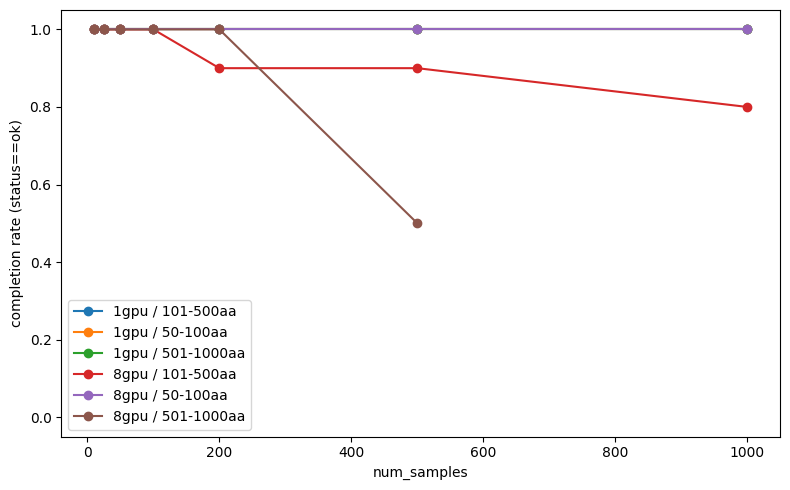

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
for (setup, sr), sub in completion.groupby(["setup", "seq_range"]):
    sub = sub.sort_values("num_samples")
    ax.plot(sub["num_samples"], sub["completion_rate"], marker="o", label=f"{setup} / {sr}")
ax.set_xlabel("num_samples")
ax.set_ylabel("completion rate (status==ok)")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()